In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Faylni o'qish
file_path = r'D:\Data_analitika_portfolio\buxoro_soliq.csv.csv'

df = pd.read_csv(file_path,
                 sep=',',
                 encoding='utf-8',
                 decimal='.',
                 skipinitialspace=True)


# 2. Ustun nomlaridagi bo'shliqlarni tozalash (eng muhim qadam!)
df.columns = df.columns.str.strip()

# 3. Toza tuman ustunlar ro'yxati
tuman_columns = [
    'olot_tumani', 'buxoro_tumani', 'vobkent_tumani', 'gijduvon_tumani',
    'kogon_tumani', 'qorakol_tumani', 'qorovulbozor_tumani', 'peshko_tumani',
    'romitan_tumani', 'jondor_tumani', 'shofirkon_tumani', 
    'buxoro_shaxar', 'kogon_shaxar'
]

# 4. Long formatga o'tkazish
df_long = df.melt(
    id_vars=['indikatorlar'],           # o'zgarmaydigan ustun
    value_vars=tuman_columns,           # tuman ustunlari
    var_name='tuman',                   # yangi ustun nomi
    value_name='tushum'                 # qiymatlar ustuni
)

# 5. Natijani ko'rish
print("Jadval muvaffaqiyatli long formatga o'tkazildi!")
print(f"Jadval hajmi: {df_long.shape}")
print("\nBirinchi 15 qator:")
print(df_long.head(15))

# Qo'shimcha: tuman nomlarini chiroyli qilish (ixtiyoriy)
df_long['tuman'] = df_long['tuman'].str.replace('_', ' ').str.title()

Jadval muvaffaqiyatli long formatga o'tkazildi!
Jadval hajmi: (182, 3)

Birinchi 15 qator:
                                    indikatorlar          tuman  tushum
0                                     daromadlar    olot_tumani   10.27
1                                 soliq_qomitasi    olot_tumani   10.85
2                                   foyda_soligi    olot_tumani    0.00
3                    aylanmadan_olinadigan_soliq    olot_tumani    0.43
4                                 daromad_soligi    olot_tumani    2.18
5                                            qqs    olot_tumani    0.00
6                                   aksiz_soligi    olot_tumani    0.11
7                                 mol_muk_soligi    olot_tumani    0.72
8                                     yer_soligi    olot_tumani    4.83
9          yer_qaridan_foydalangalik_uchun_solig    olot_tumani    0.00
10  suv_resurslaridan_foydalanganlik_uchun_solig    olot_tumani    1.46
11                                     boshqa

In [9]:
df_long.head()

,indikatorlar,tuman,tushum
0,daromadlar,Olot Tumani,10.27
1,soliq_qomitasi,Olot Tumani,10.85
2,foyda_soligi,Olot Tumani,0.00
3,aylanmadan_olinadigan_soliq,Olot Tumani,0.43
4,daromad_soligi,Olot Tumani,2.18


In [32]:
df_long.groupby("tuman")["tushum"].sum().sort_values(ascending=False).reset_index()

,tuman,tushum
0,Buxoro Shaxar,57.63
1,Gijduvon Tumani,37.45
2,Jondor Tumani,34.50
3,Buxoro Tumani,32.35
4,Olot Tumani,31.26
5,Vobkent Tumani,29.88
6,Romitan Tumani,29.87
7,Shofirkon Tumani,29.30
8,Peshko Tumani,29.07
9,Qorakol Tumani,28.04


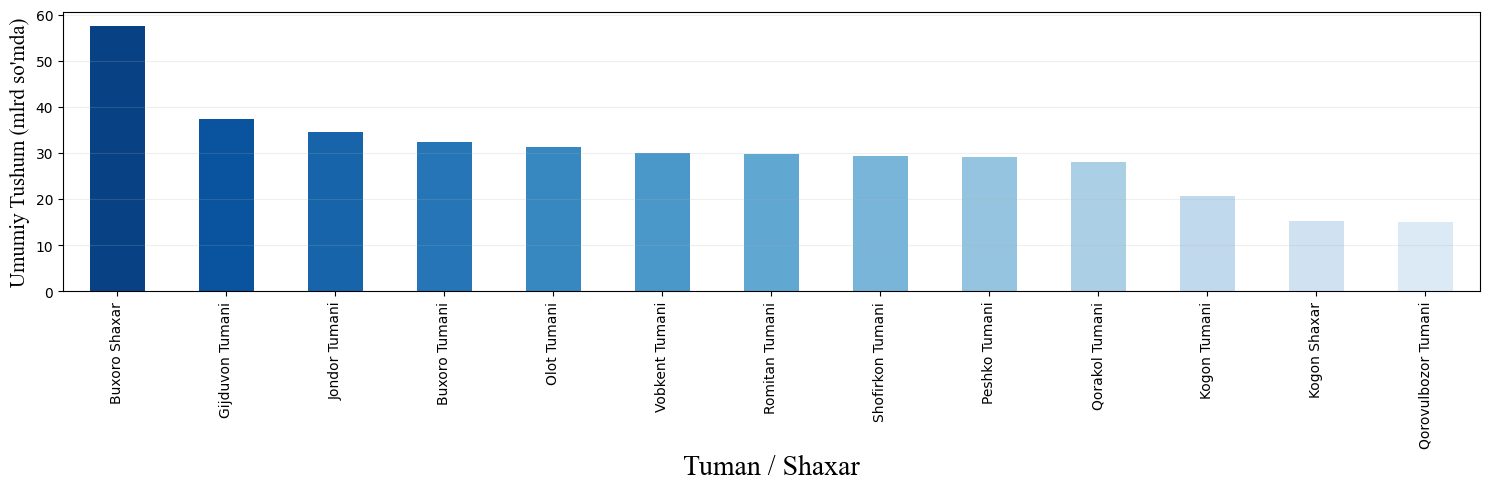

In [50]:
plt.figure(figsize=(15,5))
df_long.groupby("tuman")["tushum"].sum().sort_values(ascending=False).plot(
    kind='bar',
    color=sns.color_palette("Blues_r", n_colors=len(result))   # ko'k ranglar)  # chiroyli ranglar
)


plt.xlabel("Tuman / Shaxar", fontsize = 20,
                       family = "Times New Roman" ) 
plt.ylabel("Umumiy Tushum (mlrd so'mda)", fontsize = 15,
                            family = "Times New Roman")
plt.grid(axis="y", alpha=0.2)


plt.tight_layout()
plt.show()

In [42]:
#Eng ko'p byudjetni to'ldiradigan soliqlar
df_long.groupby("indikatorlar")["tushum"].sum().reset_index()

,indikatorlar,tushum
0,aksiz_soligi,9.55
1,aylanmadan_olinadigan_soliq,14.12
2,bojxona_qomitasi,0.00
3,boshqalar,13.45
4,daromad_soligi,28.17
5,daromadlar,130.24
6,foyda_soligi,0.00
7,iqtisodiyot_va_moliya_vazirligi,-3.18
8,mol_muk_soligi,18.76
9,qqs,0.00


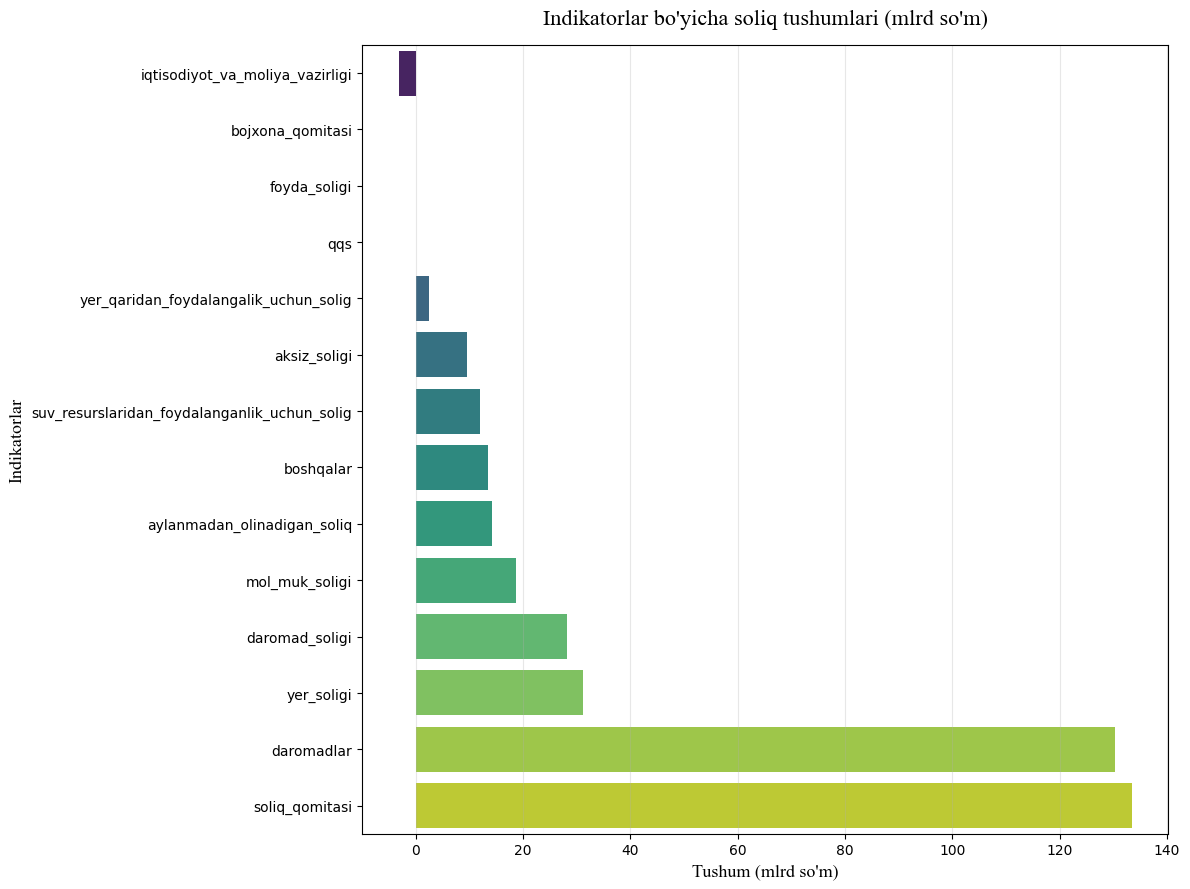

In [59]:
result = df_long.groupby("indikatorlar")["tushum"].sum().sort_values(ascending=True)

plt.figure(figsize=(12, 9))
sns.barplot(
    x=result.values, 
    y=result.index, 
    hue=result.index,
    palette="viridis",
    legend=False
)

plt.title("Indikatorlar bo'yicha soliq tushumlari (mlrd so'm)", fontsize=16, pad=15,family = "Times New Roman")
plt.xlabel("Tushum (mlrd so'm)", fontsize=13, family = "Times New Roman")
plt.ylabel("Indikatorlar", fontsize=13 , family = "Times NEw Roman")
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

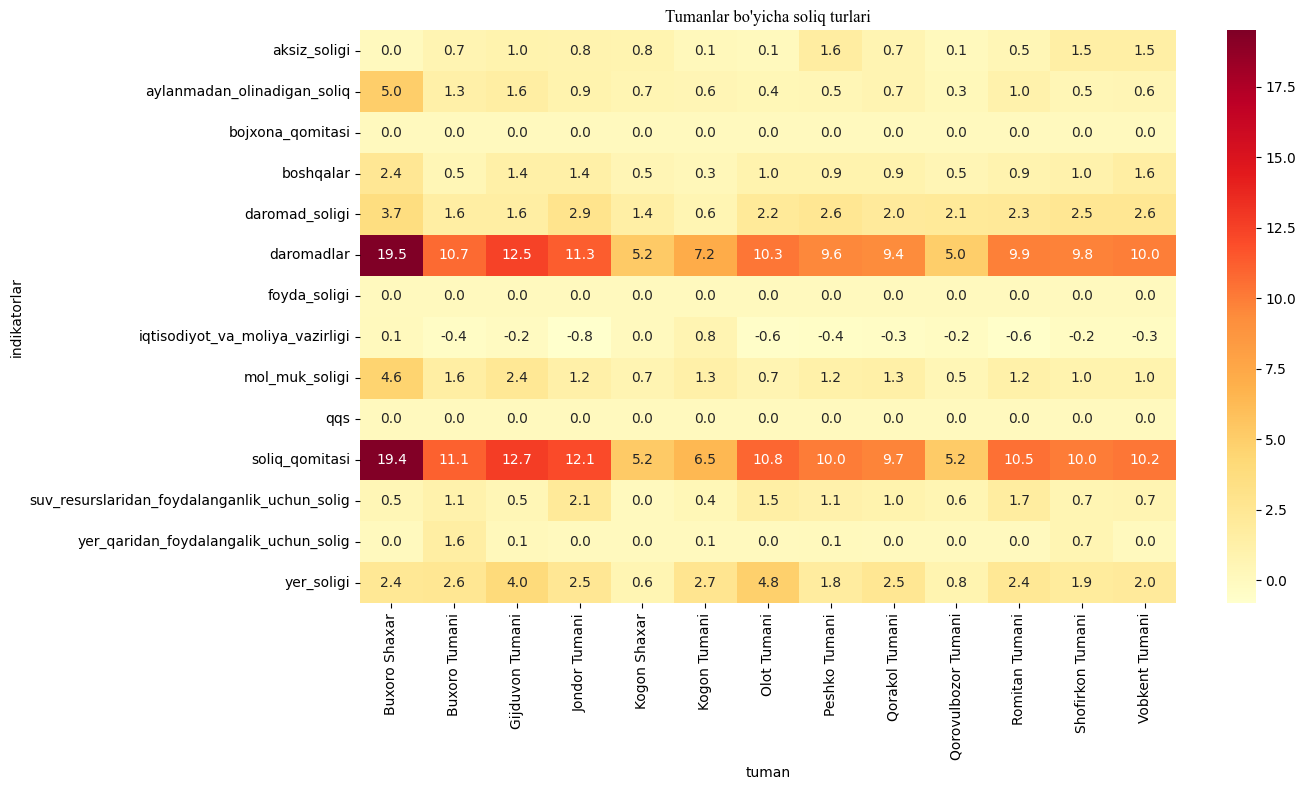

In [ ]:
# Avval pivot table yarating
df_pivot = df_long.pivot_table(
    index="indikatorlar", 
    columns="tuman", 
    values="tushum"
)

# Keyin heatmap
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    df_pivot, 
    annot=True, 
    fmt=".1f", 
    cmap="YlOrRd",
    ax=ax
)
plt.title("Tumanlar bo'yicha soliq turlari",family = "Times New Roman")
plt.tight_layout()
plt.show()

In [76]:
df_pivot = df_long.pivot_table(
    index="indikatorlar", 
    columns="tuman", 
    values="tushum"


)

df_pivot

tuman,Buxoro Shaxar,Buxoro Tumani,Gijduvon Tumani,Jondor Tumani,Kogon Shaxar,Kogon Tumani,Olot Tumani,Peshko Tumani,Qorakol Tumani,Qorovulbozor Tumani,Romitan Tumani,Shofirkon Tumani,Vobkent Tumani
indikatorlar,,,,,,,,,,,,,
aksiz_soligi,0.00,0.70,0.96,0.85,0.83,0.14,0.11,1.65,0.71,0.13,0.51,1.48,1.48
aylanmadan_olinadigan_soliq,5.00,1.27,1.57,0.93,0.66,0.58,0.43,0.52,0.73,0.29,1.03,0.51,0.60
bojxona_qomitasi,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
boshqalar,2.44,0.49,1.35,1.39,0.54,0.32,0.99,0.94,0.95,0.53,0.92,1.02,1.57
daromad_soligi,3.69,1.62,1.61,2.90,1.42,0.61,2.18,2.59,2.05,2.13,2.26,2.55,2.56
daromadlar,19.50,10.71,12.51,11.28,5.23,7.22,10.27,9.57,9.36,4.98,9.89,9.75,9.97
foyda_soligi,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
iqtisodiyot_va_moliya_vazirligi,0.12,-0.38,-0.17,-0.82,0.00,0.75,-0.58,-0.43,-0.35,-0.22,-0.60,-0.24,-0.26
mol_muk_soligi,4.59,1.64,2.38,1.25,0.73,1.28,0.72,1.21,1.34,0.47,1.20,0.98,0.97


In [109]:
df_short = df[["indikatorlar","davlat_byudjeti","respublika_byudjeti","buxoro_viloyati"]]

df_short

,indikatorlar,davlat_byudjeti,respublika_byudjeti,buxoro_viloyati
0,daromadlar,27269.86,21846.63,363.97
1,soliq_qomitasi,21089.41,15666.70,366.59
2,foyda_soligi,5478.80,5478.07,0.02
3,aylanmadan_olinadigan_soliq,211.45,0.00,14.10
4,daromad_soligi,2971.24,1216.26,130.99
5,qqs,4560.23,4560.23,0.00
6,aksiz_soligi,141659.00,937.55,33.63
7,mol_muk_soligi,628.80,0.00,38.87
8,yer_soligi,742.57,0.00,51.34
9,yer_qaridan_foydalangalik_uchun_solig,2057.07,2018.54,2.52


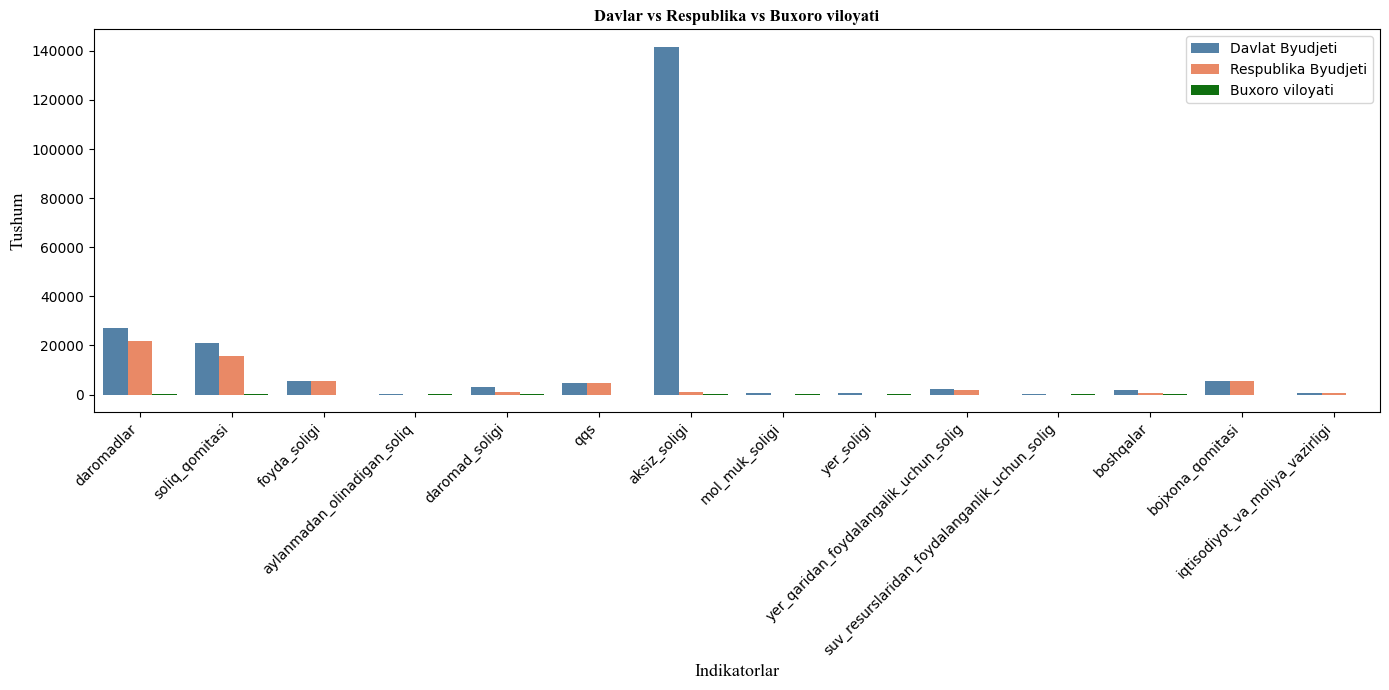

In [148]:
import matplotlib.pyplot as plt
import numpy as np

df_short = df[["indikatorlar","davlat_byudjeti", "respublika_byudjeti", "buxoro_viloyati"]].melt(
    id_vars="indikatorlar",
    var_name="byudjet",
    value_name="summa"
)

fig, ax = plt.subplots(figsize=(14, 7))

sns.barplot(
    data=df_short,
    x="indikatorlar",
    y="summa",
    hue="byudjet",
    palette=["steelblue", "coral", "green"],
    ax=ax
)

plt.xticks(rotation=45, ha="right")
plt.title("Davlar vs Respublika vs Buxoro viloyati", fontweight="bold", family = "Times New Roman")
plt.xlabel("Indikatorlar" , fontsize = 13 , family = "Times New Roman")
plt.ylabel("Tushum" , fontsize = 13 , family = "Times New Roman")
handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=["Davlat Byudjeti", "Respublika Byudjeti", "Buxoro viloyati"]
)
plt.tight_layout()
plt.show()


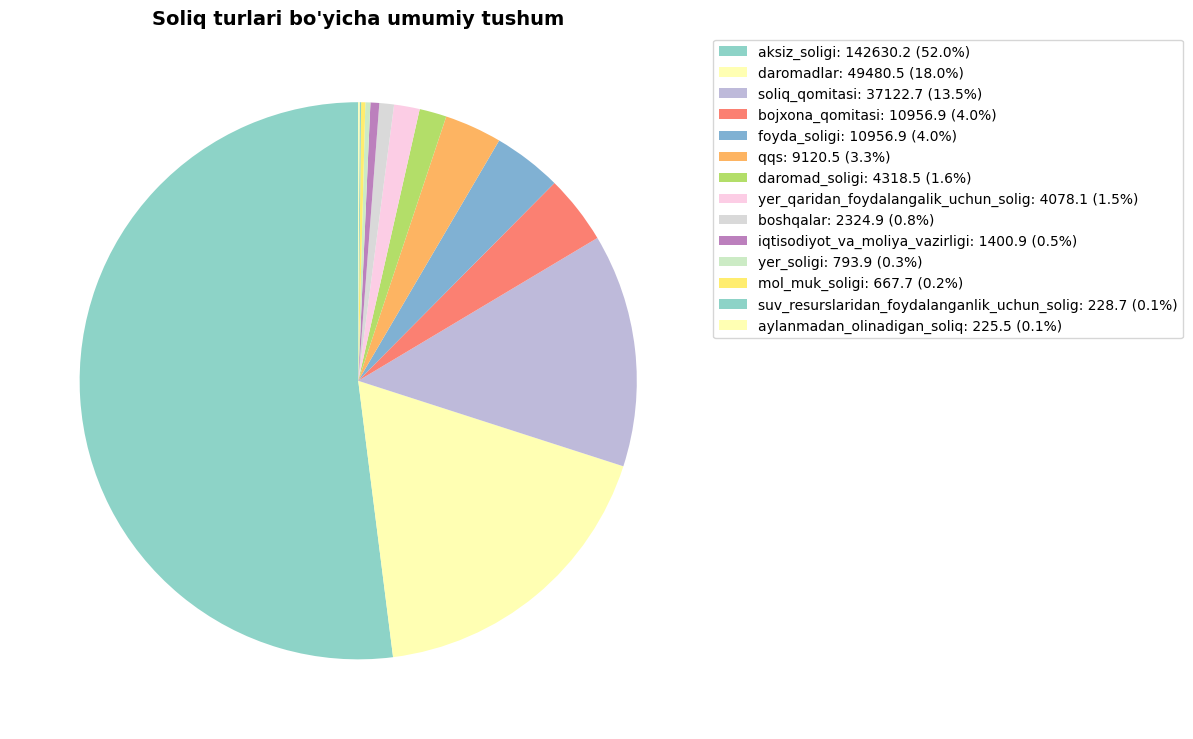

In [ ]:
top_pie = df_short.groupby("indikatorlar")["summa"].sum().sort_values(ascending=False)

# Foizni hisoblash
jami = top_pie.sum()
foizlar = (top_pie.values / jami * 100)

fig, ax = plt.subplots(figsize=(12, 12))

wedges, texts = ax.pie(
    top_pie.values,
    labels=None,
    colors=sns.color_palette("Set3", len(top_pie)),
    startangle=90,
)

# Legend da qiymat + foiz
ax.legend(
    wedges,
    [f"{label}: {value:.1f} ({foiz:.1f}%)" 
     for label, value, foiz in zip(top_pie.index, top_pie.values, foizlar)],
    loc="upper left",
    bbox_to_anchor=(1, 1),
    fontsize=10
)e

ax.set_title("Soliq turlari bo'yicha umumiy tushum", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()